In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf
import os

#Fonctions d'erreur à fitter#



In [3]:
def erreur(x,Imax,x0,w):
    return (Imax/2)*(1-erf(np.sqrt(2)*(x-x0)/w))

In [4]:
donnees = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS')

distance = [float(i.replace('cm','').replace('_','.')) for i in donnees]

elDic = dict(zip(distance,donnees)) #permet de trier les valeurs selon la distance
laDica = dict(sorted(elDic.items())) #me creer un dictionnaire qui est ordonné selon la distance
for i in laDica:
    print(laDica[i])
    spectre = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS\\{laDica[i]}')
    #plt.scatter(spectre[1:,0],spectre[1:,1])
    #plt.show()

16cm
17cm
18cm
19cm
20cm
21cm
22cm
23cm
24cm
25cm
26cm
27cm
28cm
29cm
30cm
31cm
46cm
61cm
76cm
91cm
106cm
121cm
136cm
142cm


In [5]:
ws = np.zeros(24)
for k,i in enumerate(laDica):
    spectre = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\GAUSS_AR_NS\\{laDica[i]}')
    x = spectre[1:,0]
    y = spectre[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    ws[k]=popt[2]
    
    print(np.sqrt(pcov[2,2]),popt[2])
    #print(laDica[i])
    #X = np.arange(min(x),max(x))
    #plt.scatter(x,y)
    #plt.plot(X,erreur(X,*popt),color='black')
    #plt.show()

2.664405436783866 274.85024752930326
0.5559104452491938 251.9682641768505
0.5228042856608532 250.91143177379618
1.2944979447499374 267.1623395490464
0.35808467093188273 254.79815125875925
0.3259920371849965 255.97201270075993
0.3128802144187629 258.0432860649016
0.289664004303292 261.281014913748
0.2543462783195343 263.5696484467843
0.22072988373352428 264.93494938562264
0.162963241622608 264.0558670568966
0.255303122857118 271.5079855521248
0.2778261706049896 272.3899268760472
0.2524222962865746 279.1781628878462
0.4536271193586684 275.32522106592324
0.446073657987686 283.95880775209395
0.5719071436636332 359.0759654798499
0.44443189817251133 455.5338692016594
0.28157957890924556 579.1428820083922
0.36772830725375877 708.625010006552
0.5456755917285958 819.6645508669529
0.8512194083130242 952.9473478801441
0.6174370425725757 1081.3753850569544
0.8779532343261084 1122.8377466520562


240.22608494401746 0.1199056850889059


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\graphes\\fitz0.png'

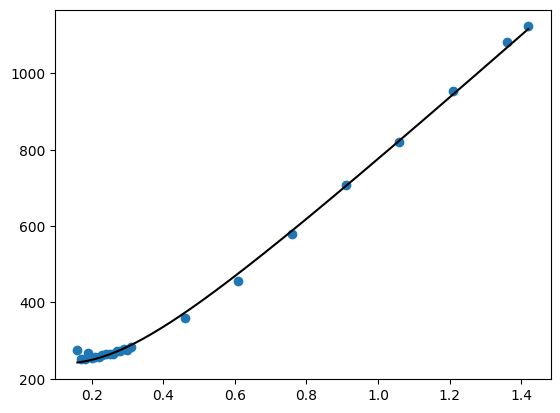

In [6]:
z = np.array(list(laDica.keys()))/100
def courbeQuad(z,w0,z0): #rappel w est en micron et z en cm
    zR = np.pi*(w0*1e-06)**2/(632.8*1e-09) #m
    
    return w0 * np.sqrt(1+ ((z-z0)/(zR))**2) #ici il fallait convertir zR dans les mêmes unités que z

w0_0 = ws.min()
z0_0 = z[ws.argmin()]
p0 = [w0_0,z0_0]
bounds = ([0,-np.inf],[np.inf,np.inf])
popt,pcov = curve_fit(courbeQuad,z,ws,p0=p0,bounds=bounds, maxfev=200000)
w0_fit, z0_fit = popt
print(w0_fit, z0_fit)

Z = np.linspace(z.min(),z.max(),200)
plt.scatter(z,ws)
plt.plot(Z,courbeQuad(Z,*popt),color='black')
plt.savefig('graphes\\fitz0.png')


In [7]:
zRfit0 = (w0_fit*1e-06)**2*np.pi/(632.8*1e-09)
print(f'zR={zRfit0:.2f}m')

zR=0.29m


In [17]:
donnees1lentille = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille1')

distance1lent = [float(i.replace('cm','').replace('_l1','').replace('p','.')) for i in donnees1lentille]

dic1lent_no = dict(zip(distance1lent,donnees1lentille)) #permet de trier les valeurs selon la distance
dic1lent = dict(sorted(dic1lent_no.items())) #me creer un dictionnaire qui est ordonné selon la distance
for i in dic1lent:
    print(dic1lent[i])
    spectre1lent = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille1\\{dic1lent[i]}')
    #plt.scatter(spectre1lent[1:,0],spectre1lent[1:,1])
    #plt.show()

14cm_l1
14p5_l1
15cm_l1
16cm_l1
17cm_l1
18cm_l1
19cm_l1
20cm_l1
21cm_l1
22cm_l1
23cm_l1
24cm_l1
25cm_l1
35cm_l1
45cm_l1
55cm_l1
65cm_l1
75cm_l1


In [18]:
ws1lent = np.zeros(len(dic1lent))
for k,i in enumerate(dic1lent):
    spectre1lent = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille1\\{dic1lent[i]}')
    x = spectre1lent[1:,0]
    y = spectre1lent[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    ws1lent[k]=popt[2]
    
    print(np.sqrt(pcov[2,2]),popt[2])
    print(dic1lent[i])
    #X = np.arange(min(x),max(x))
    #plt.scatter(x,y)
    #plt.plot(X,erreur(X,*popt),color='black')
    #plt.show()

0.5336596104199216 214.8798337241847
14cm_l1
0.8456789877376832 210.70269365333286
14p5_l1
0.5872381810960771 170.77495508151515
15cm_l1
0.6605076218863941 171.06640768416904
16cm_l1
0.5520694525699366 173.11767175055056
17cm_l1
0.7446934891246514 161.7956696080224
18cm_l1
2.7591485460612577 142.69408701031347
19cm_l1
2.696429535935041 144.97400703342672
20cm_l1
1.8595169500673017 150.4771673672845
21cm_l1
1.3817414730238808 168.1494976015451
22cm_l1
0.39487353742947945 165.65384009504112
23cm_l1
0.6757668808293646 170.410072986934
24cm_l1
0.4283769289074073 167.64469877616398
25cm_l1
0.5194946916018643 239.93972406807674
35cm_l1
0.8759224898649725 329.0019601060734
45cm_l1
0.8257623529673522 453.1332933964857
55cm_l1
1.201708926148256 545.0539684573204
65cm_l1
1.398184594138178 632.2693882725869
75cm_l1


166.82476165659682 0.2187352497421444


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\graphes\\fitz0_1.png'

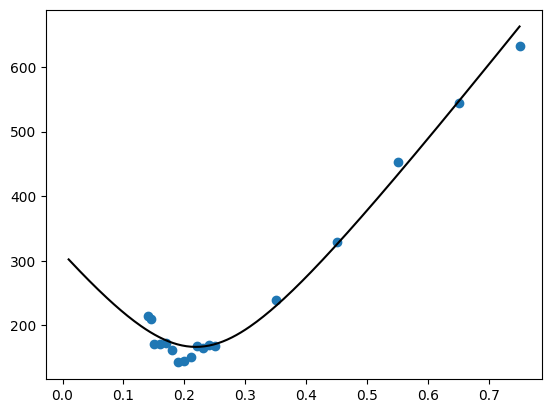

In [29]:
z_1lent = np.array(list(dic1lent.keys()))/100

w0_1 = ws1lent.min()
z0_1 = z[ws1lent.argmin()]
p01 = [w0_1,z0_1]
bounds = ([0,-np.inf],[np.inf,np.inf])
popt,pcov = curve_fit(courbeQuad,z_1lent,ws1lent,p0=p01,bounds=bounds, maxfev=200000)
w01_fit, z01_fit = popt
print(w01_fit, z01_fit)

Z = np.linspace(0.01,z_1lent.max(),200)
plt.scatter(z_1lent,ws1lent)
plt.plot(Z,courbeQuad(Z,*popt),color='black')
plt.savefig('graphes\\fitz0_1.png')


In [30]:
##################################### Partie théorique pour les q' ##################################

def UnSurq_z(q,A,B,C,D):
    return  ( C+D*(1/q) ) / ( A + B*(1/q) )

q_z1 = 1j*zRfit0
unsurq2 = UnSurq_z(q_z1,1,0.03,0,1)
q_z2 = 1/unsurq2
unsurq3 = UnSurq_z(q_z2,1,0,-1/.20,1)

#####################################################################################################

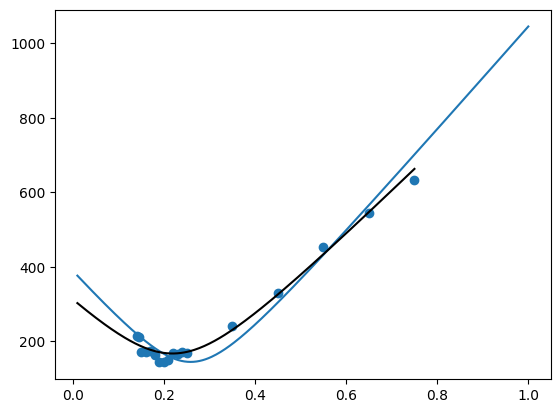

In [31]:
##################################### Comparaison théorie vs expérimentale pour 1 lentille ##########

ztheo1 = np.linspace(.01,1,300)

w_z3 = np.zeros(len(ztheo1))
for k,i in enumerate(ztheo1):
    #print(k,i/100)
    Q = UnSurq_z(1/unsurq3,1,(i-.1199),0,1)
    #print(Q)
    Q=Q.imag
    w_z3[k] = np.sqrt( -(632.8e-09)/(np.pi*Q))
    #print(w_z3*1000000)
    
plt.plot(ztheo1,w_z3*1000000)
plt.plot(Z,courbeQuad(Z,*popt),color='black')
plt.scatter(z_1lent,ws1lent)



In [32]:
print(f'{ztheo1[np.argmin(w_z3)]}m,{w_z3.min() * 1000000}um')

0.2583277591973244m,144.22013743451006um


2 LENTILLES


In [ ]:
donnees2lentille = os.listdir('C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille2')

distance2lent = [float(i.replace('cm','').replace('_l2','').replace('p','.')) for i in donnees2lentille]

dic2lent_no = dict(zip(distance2lent,donnees2lentille)) #permet de trier les valeurs selon la distance
dic2lent = dict(sorted(dic2lent_no.items())) #me creer un dictionnaire qui est ordonné selon la distance

ws2lent = np.zeros(len(dic2lent))
for k,i in enumerate(dic2lent):
    print(dic2lent[i])
    spectre2lent = np.loadtxt(f'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\donnees\\lentille2\\{dic2lent[i]}')
    
    #######################Si je veux voir que les graphes#################################################
    #plt.scatter(spectre2lent[1:,0],spectre2lent[1:,1])
    #plt.show()
    #######################################################################################################
    
    
    x = spectre2lent[1:,0]
    y = spectre2lent[1:,1]
    #on doit approximer les paramètres pour que curve_fit fonctionne
    Imax0 = max(y)-min(y)
    x0_0 = x[(np.argmax(np.gradient(y)))]
    w0 = (max(x)-min(x))/10
    p0 = [Imax0,x0_0,w0]
    popt,pcov = curve_fit(erreur,x,y,p0=p0)
    ws2lent[k]=popt[2]
    
    print(np.sqrt(pcov[2,2]),popt[2])
    print(dic2lent[i])
    X = np.arange(min(x),max(x))
    
    ########################Si je veux voir les graphes avec le curve_fit####################################
    plt.scatter(x,y)
    plt.plot(X,erreur(X,*popt),color='black')
    plt.show()
    #########################################################################################################

107.90352701005676 0.35178381579188706


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\simar\\PycharmProjects\\courslabo3\\LaboGaussien\\graphes\\fitz0_2.png'

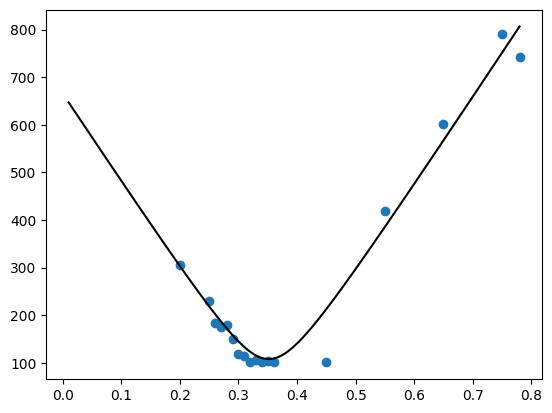

In [34]:
############################ W vs Z pour 2 lentilles convergentes ###########################################
z_2lent = np.array(list(dic2lent.keys()))/100

w0_2 = ws2lent.min()
z0_2 = z[ws2lent.argmin()]
p02 = [w0_2,z0_2]
bounds = ([0,-np.inf],[np.inf,np.inf])
popt,pcov = curve_fit(courbeQuad,z_2lent,ws2lent,p0=p02,bounds=bounds, maxfev=200000)
w02_fit, z02_fit = popt
print(w02_fit, z02_fit)

Z = np.linspace(0.01,z_2lent.max(),200)
plt.scatter(z_2lent,ws2lent)
plt.plot(Z,courbeQuad(Z,*popt),color='black')
plt.savefig('graphes\\fitz0_2.png')
#############################################################################################################

In [48]:
############################### Calcul du parcours optique depuis la 1ere lentille jusqu'à la 2ieme ###################################
q_z3 = 1/unsurq3
unsurq4 = UnSurq_z(q_z3,1,0.50,0,1)
q_z4 = 1/unsurq4
unsurq5 = UnSurq_z(q_z4,1,0,-1/.15,1)
ztheo2 = np.linspace(.01,1,300)
#######################################################################################################################################

w_z5 = np.zeros(len(ztheo2))
for k,i in enumerate(ztheo2):
    print(k,i/100)
    Q = UnSurq_z(1/unsurq3,1,(i-.1199),0,1)
    print(Q)
    Q=Q.imag
    w_z3[k] = np.sqrt( -(632.8e-09)/(np.pi*Q))
    #print(w_z3*1000000)
    
plt.plot(ztheo1,w_z3*1000000)
plt.plot(Z,courbeQuad(Z,*popt),color='black')
plt.scatter(z_1lent,ws1lent)

unsurq5

(-4.107717126956036-0.7314082370460183j)